# Phase 1 - Physics foundations

1. **reference frames and rotations** : how to describe where the aircraft points;
2. **the standard atmosphere** : air density, pressure, speed of sound versus altitude;
3. **the numerical integrator** : how to advance the equations of motion in time.

Code: `src/jetsim/core/` (`frames.py`, `atmosphere.py`, `integrators.py`), tested in
`tests/test_frames.py`, `test_atmosphere.py`, `test_integrators.py`.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np

from jetsim.core import frames as fr
from jetsim.core.atmosphere import (
    calibrated_airspeed,
    dynamic_pressure,
    isa,
)
from jetsim.core.integrators import euler_step, rk4_step, simulate, substeps_per_control
from jetsim.viz.style import GRID, INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180

## 1. Reference frames

Three frames are used everywhere:

* **NED** (North-East-Down): the inertial frame, fixed to a flat Earth. Altitude is $h = -z$.
* **Body** (Forward-Right-Down): attached to the aircraft — $x_b$ out of the nose,
  $y_b$ out of the right wing, $z_b$ out of the belly.
* **Wind**: $x_w$ along the velocity vector. It differs from the body frame by the
  **angle of attack** $\alpha$ and the **sideslip** $\beta$:

$$\alpha = \operatorname{atan2}(w, u), \qquad \beta = \arcsin(v / V)$$

where $(u, v, w)$ is the velocity in body axes. Aerodynamic forces are naturally expressed in
the wind frame (drag along $-x_w$, lift along $-z_w$), while moments of inertia live in the
body frame, so both are needed.

### Rotation matrices and Euler angles

The orientation of the body relative to NED can be described by three **Euler angles** applied
in the aeronautical 3-2-1 order: heading $\psi$ (yaw), then pitch $\theta$, then roll $\phi$:

$$C_{nb} = R_z(\psi)\,R_y(\theta)\,R_x(\phi), \qquad v_{ned} = C_{nb}\, v_{body}$$

Here is the body frame of an aircraft heading 40° (north-east), nose up 20°, banked 45° right:

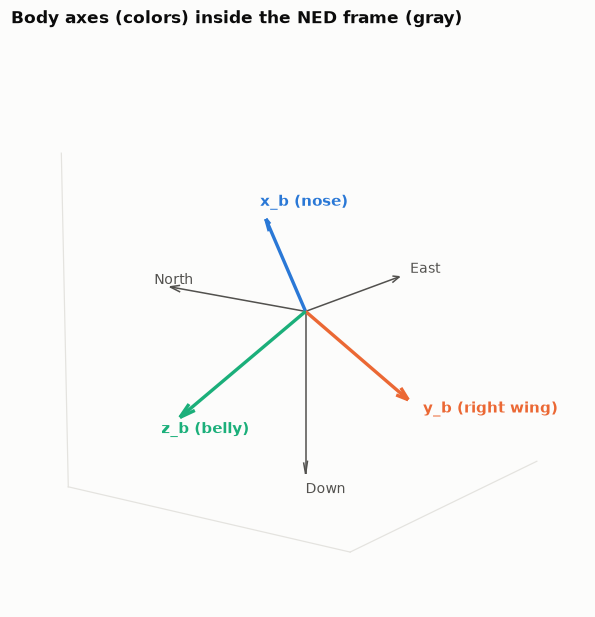

In [2]:
C = fr.dcm_from_euler(phi=45 * DEG, theta=20 * DEG, psi=40 * DEG)

fig = plt.figure(figsize=(6.5, 5.5), layout="constrained")
ax = fig.add_subplot(projection="3d")


def to_plot(v):
    """NED -> plotting axes (East, North, Up) so that 'up' is up on screen."""
    return np.array([v[1], v[0], -v[2]])


for k, name in enumerate(("North", "East", "Down")):
    e = to_plot(np.eye(3)[k])
    ax.quiver(0, 0, 0, *e, color=INK_2, linewidth=1, arrow_length_ratio=0.08)
    ax.text(*(1.12 * e), name, color=INK_2, fontsize=9)
labels = ("x_b (nose)", "y_b (right wing)", "z_b (belly)")
for k, (name, color) in enumerate(zip(labels, SERIES, strict=True)):
    e = to_plot(C[:, k])  # column k of C_nb = body axis k expressed in NED
    ax.quiver(0, 0, 0, *e, color=color, linewidth=2.2, arrow_length_ratio=0.1)
    ax.text(*(1.15 * e), name, color=color, fontsize=10, fontweight="bold")
ax.set_xlim(-1, 1), ax.set_ylim(-1, 1), ax.set_zlim(-1, 1)
ax.set_xticks([]), ax.set_yticks([]), ax.set_zticks([])
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_pane_color((1, 1, 1, 0))
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=15, azim=215)  # chase view, from behind and to the left
ax.set_title("Body axes (colors) inside the NED frame (gray)", loc="left")
plt.show()

The columns of $C_{nb}$ are simply the body axes expressed in NED, that is what the plot
draws. $C_{nb}$ is orthonormal, so its inverse is its transpose: $C_{bn} = C_{nb}^T$.

## 2. Why quaternions: gimbal lock

Euler angles are great for humans, but **singular at $\theta = \pm 90°$**. Their time
derivatives, given the body rotation rates $(p, q, r)$, are

$$\dot\phi = p + (q\sin\phi + r\cos\phi)\tan\theta, \quad
  \dot\theta = q\cos\phi - r\sin\phi, \quad
  \dot\psi = \frac{q\sin\phi + r\cos\phi}{\cos\theta}$$

which blow up when $\cos\theta \to 0$ the nose pointing straight up, exactly what happens in
the middle of a loop or an Immelmann.

The project therefore integrates a **unit quaternion** $q = [q_0, q_1, q_2, q_3]$. A rotation by
angle $\vartheta$ about unit axis $n$ is $q = [\cos\frac{\vartheta}{2},\ n \sin\frac{\vartheta}{2}]$,
and its kinematics are singularity-free:

$$\dot q = \tfrac12\, q \otimes [0,\ \omega_b], \qquad \omega_b = [p, q, r]$$

**Experiment:** a perfect loop, a constant pitch rate of 30°/s for 12 s (360°). We integrate
the quaternion, then *read* the Euler angles from it.

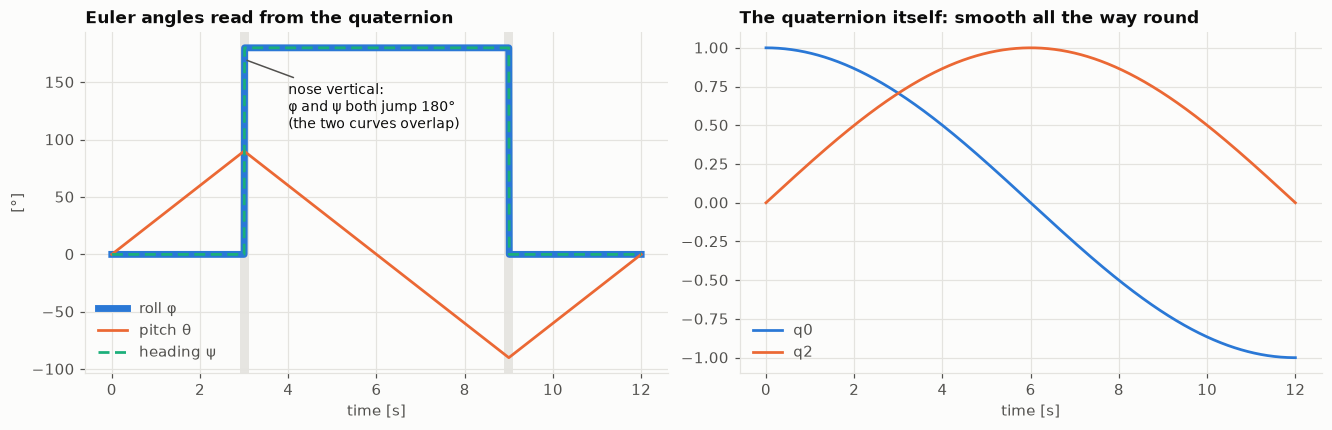

In [3]:
omega = np.array([0.0, 30 * DEG, 0.0])  # pure pitch rate [rad/s]


def attitude_dynamics(t, q, u):
    return fr.quat_derivative(q, omega)


res = simulate(attitude_dynamics, fr.quat_identity(), 12.0, dt=0.01, post_step=fr.quat_normalize)
euler = np.degrees([fr.euler_from_quat(q) for q in res.x])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
styles = (("roll φ", 4.5, "-"), ("pitch θ", 1.8, "-"), ("heading ψ", 1.8, (0, (4, 2))))
for k, ((name, lw, ls), color) in enumerate(zip(styles, SERIES, strict=True)):
    axes[0].plot(res.t, euler[:, k], color=color, label=name, linewidth=lw, linestyle=ls)
axes[0].axvspan(2.9, 3.1, color=GRID, alpha=0.9, linewidth=0)
axes[0].axvspan(8.9, 9.1, color=GRID, alpha=0.9, linewidth=0)
axes[0].annotate(
    "nose vertical:\nφ and ψ both jump 180°\n(the two curves overlap)",
    (3.0, 170),
    xytext=(4.0, 110),
    color=INK,
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": INK_2},
)
axes[0].set_title("Euler angles read from the quaternion")
axes[0].set_xlabel("time [s]"), axes[0].set_ylabel("[°]")
axes[0].legend(loc="lower left")
for k, (name, color) in enumerate(zip(("q0", "q2"), (SERIES[0], SERIES[1]), strict=True)):
    axes[1].plot(res.t, res.x[:, 0 if k == 0 else 2], color=color, label=name)
axes[1].set_title("The quaternion itself: smooth all the way round")
axes[1].set_xlabel("time [s]")
axes[1].legend(loc="lower left")
plt.show()

The aircraft motion is perfectly smooth, but the Euler description jumps: at the vertical,
"pitching past 90°" is re-described as "pitch decreasing, heading +180°, roll 180°" (flying
inverted the other way). This is not just cosmetic: in phase 8, an aerobatics agent observed
Euler angles, "believed it was upside down" at the top of the loop, and stopped there. The fix
was to observe the **direction of gravity** in body and wind axes instead ([notebook 7](https://github.com/elouansalaun/jetfighter-rl/blob/main/notebooks/07_gym_environment.ipynb)).

### Conversions are exact to machine precision

Round trips Euler → quaternion → matrix → Euler are tested on random attitudes
(`tests/test_frames.py` requires 1e-9; the worst error measured here is far smaller):

In [4]:
rng = np.random.default_rng(0)
worst = 0.0
for _ in range(10_000):
    phi, psi = rng.uniform(-math.pi, math.pi, 2)
    theta = rng.uniform(-math.pi / 2 + 1e-3, math.pi / 2 - 1e-3)
    q = fr.quat_from_euler(phi, theta, psi)
    C1 = fr.dcm_from_quat(q)
    C2 = fr.dcm_from_euler(phi, theta, psi)
    back = fr.euler_from_dcm(fr.dcm_from_quat(fr.quat_from_dcm(C1)))
    err = max(np.abs(C1 - C2).max(), np.abs(np.array(back) - (phi, theta, psi)).max())
    worst = max(worst, err)
print(f"worst round-trip error over 10,000 random attitudes: {worst:.1e}")

worst round-trip error over 10,000 random attitudes: 2.3e-13


### Keeping the quaternion unit-length

Only *unit* quaternions are rotations. Numerical integration slowly breaks $|q| = 1$, so the
project **renormalizes after every step** (`post_step`). How fast does the norm drift without
it? Integrating a tumbling motion for 10 minutes:

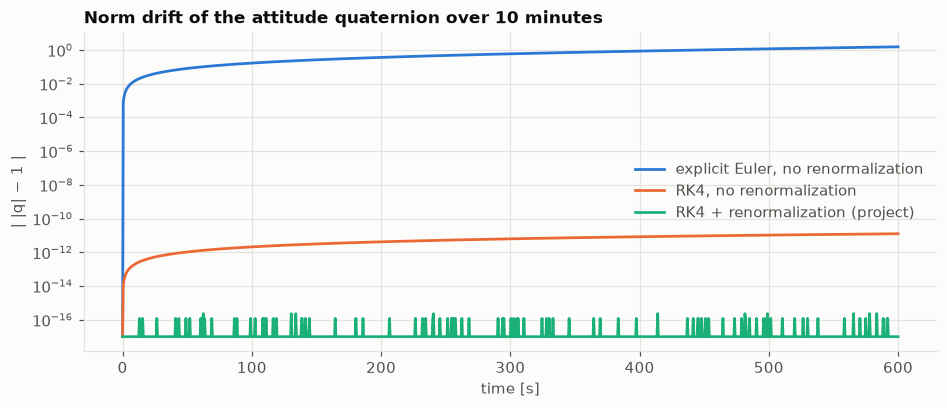

In [5]:
omega_tumble = np.array([1.0, 0.4, -0.3])  # rad/s


def tumble(t, q, u):
    return fr.quat_derivative(q, omega_tumble)


fig, ax = plt.subplots(figsize=(8.5, 3.6), layout="constrained")
cases = [
    ("explicit Euler, no renormalization", "euler", None),
    ("RK4, no renormalization", "rk4", None),
    ("RK4 + renormalization (project)", "rk4", fr.quat_normalize),
]
for (label, method, post), color in zip(cases, SERIES, strict=True):
    r = simulate(tumble, fr.quat_identity(), 600.0, dt=0.01, method=method, post_step=post)
    drift = np.abs(np.linalg.norm(r.x, axis=1) - 1.0) + 1e-17
    ax.semilogy(r.t[::50], drift[::50], color=color, label=label)
ax.set_xlabel("time [s]"), ax.set_ylabel("| |q| − 1 |")
ax.set_title("Norm drift of the attitude quaternion over 10 minutes")
ax.legend(loc="center right")
plt.show()

RK4 alone is already excellent (drift ~1e-11 after 10 minutes), but renormalizing costs nothing and keeps the
norm at machine precision indefinitely : important for long RL training episodes.

## 3. The International Standard Atmosphere (ISA)

Air properties drive everything: lift and drag scale with density $\rho$, engine thrust drops
with altitude, and Mach number depends on the local speed of sound. The ISA model is made of
layers with a constant temperature gradient $L$ (in *geopotential* altitude $H$):

$$T = T_b + L\,(H - H_b), \qquad
  P = P_b \left(\frac{T}{T_b}\right)^{-g_0/(L R)} \ \ (L \ne 0), \qquad
  P = P_b\, e^{-g_0 (H - H_b)/(R T_b)} \ \ (L = 0)$$

then $\rho = P/(RT)$ and $a = \sqrt{\gamma R T}$. The layers are the troposphere
($L = -6.5$ K/km up to 11 km), an isothermal tropopause (to 20 km), and the stratosphere.

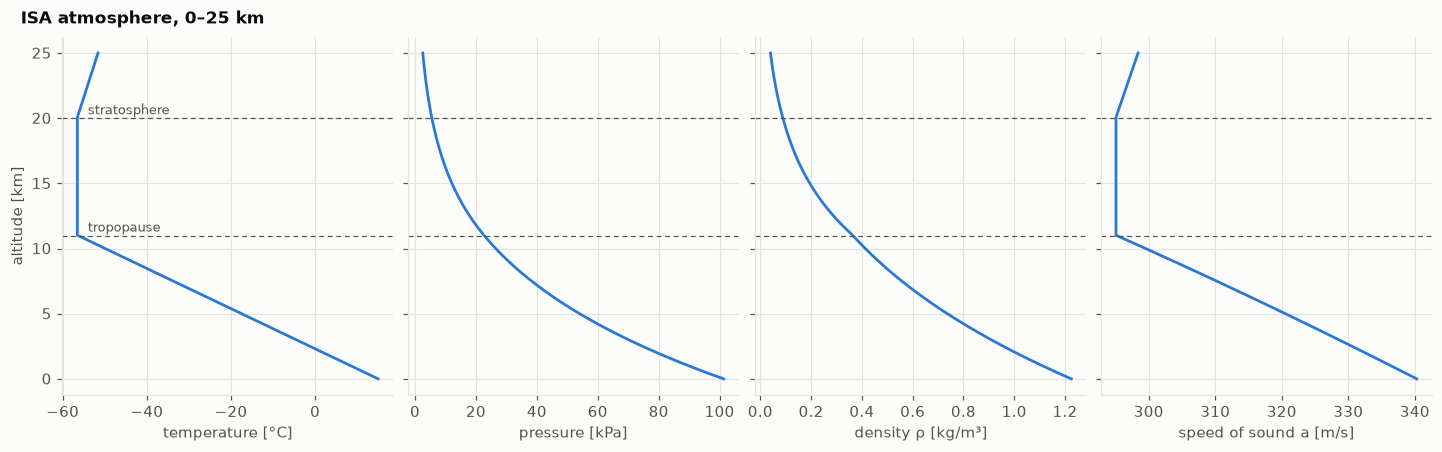

check                            model   reference
ρ at sea level [kg/m³]          1.2250      1.2250
a at sea level [m/s]          340.2940    340.3000
T at 11 km [K]                216.6500    216.6500
ρ at 11 km [kg/m³]              0.3639      0.3639


In [4]:
h = np.linspace(0, 25_000, 500)
atm = isa(h)
panels = [
    (atm.temperature - 273.15, "temperature [°C]"),
    (atm.pressure / 1000, "pressure [kPa]"),
    (atm.density, "density ρ [kg/m³]"),
    (atm.speed_of_sound, "speed of sound a [m/s]"),
]
fig, axes = plt.subplots(1, 4, figsize=(13, 4), sharey=True, layout="constrained")
for ax, (values, label) in zip(axes, panels, strict=True):
    ax.plot(values, h / 1000, color=SERIES[0])
    ax.set_xlabel(label)
    for boundary in (11, 20):
        ax.axhline(boundary, color=INK_2, linewidth=0.8, linestyle=(0, (4, 3)))
axes[0].set_ylabel("altitude [km]")
axes[0].text(-54, 11.3, "tropopause", color=INK_2, fontsize=8.5)
axes[0].text(-54, 20.3, "stratosphere", color=INK_2, fontsize=8.5)
fig.suptitle("ISA atmosphere, 0–25 km", color=INK, fontweight="bold", x=0.01, ha="left")
plt.show()

print(f"{'check':<28}{'model':>10}{'reference':>12}")
for name, value, ref in [
    ("ρ at sea level [kg/m³]", isa(0.0).density, 1.225),
    ("a at sea level [m/s]", isa(0.0).speed_of_sound, 340.3),
    ("T at 11 km [K]", isa(11_000.0, geometric=False).temperature, 216.65),
    ("ρ at 11 km [kg/m³]", isa(11_000.0, geometric=False).density, 0.3639),
]:
    print(f"{name:<28}{value:>10.4f}{ref:>12.4f}")

At 11 km the air is **3.4 times thinner** than at sea level. Two consequences we will meet
again:

* **dynamic pressure** $\bar q = \frac12 \rho V^2$ : the quantity that sets aerodynamic forces 
  is much smaller at altitude for the same true airspeed, so control laws must adapt their gains
  (*gain scheduling*, notebook 6);
* the airspeed indicator in the cockpit (**calibrated airspeed**, CAS) reads much less than the
  true airspeed at altitude:

In [5]:
for alt in (0, 5000, 11_000):
    V = 250.0
    print(
        f"h = {alt:>6} m, true airspeed 250 m/s -> "
        f"q̄ = {dynamic_pressure(V, alt) / 1000:5.1f} kPa,"
        f" CAS = {calibrated_airspeed(V, alt):5.1f} m/s"
    )

h =      0 m, true airspeed 250 m/s -> q̄ =  38.3 kPa, CAS = 250.0 m/s
h =   5000 m, true airspeed 250 m/s -> q̄ =  23.0 kPa, CAS = 200.1 m/s
h =  11000 m, true airspeed 250 m/s -> q̄ =  11.4 kPa, CAS = 145.6 m/s


## 4. Numerical integration

Every model in the project (3-DOF, 6-DOF, later the missile) is written as a first-order ODE
$\dot x = f(t, x, u)$ with the control $u$ held constant during a step (zero-order hold, like a
flight computer). The default integrator is the classic 4th-order **Runge-Kutta**:

$$k_1 = f(t, x),\quad k_2 = f(t+\tfrac{h}{2}, x+\tfrac{h}{2}k_1),\quad
  k_3 = f(t+\tfrac{h}{2}, x+\tfrac{h}{2}k_2),\quad k_4 = f(t+h, x+h k_3)$$
$$x_{n+1} = x_n + \tfrac{h}{6}\,(k_1 + 2k_2 + 2k_3 + k_4)$$

Its global error scales as $h^4$, versus $h$ for explicit Euler. We check this on a harmonic
oscillator $\ddot y = -\omega^2 y$, whose exact solution is known.

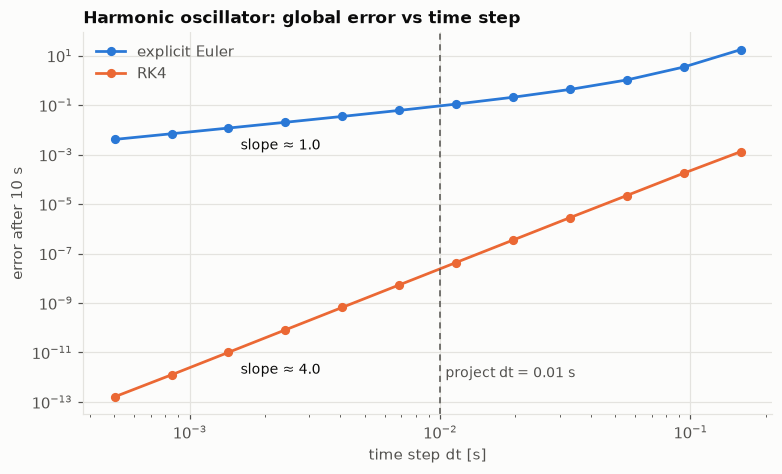

In [6]:
w = 2.0  # rad/s


def oscillator(t, x, u):
    return np.array([x[1], -w * w * x[0]])


dts = np.logspace(-3.3, -0.8, 12)
errors = {"euler": [], "rk4": []}
T = 10.0
for dt in dts:
    n = round(T / dt)
    dt_eff = T / n
    for method, step in (("euler", euler_step), ("rk4", rk4_step)):
        x = np.array([1.0, 0.0])
        for k in range(n):
            x = step(oscillator, k * dt_eff, x, np.zeros(0), dt_eff)
        errors[method].append(abs(x[0] - math.cos(w * T)))

fig, ax = plt.subplots(figsize=(7, 4.2), layout="constrained")
for (method, label), color in zip(
    (("euler", "explicit Euler"), ("rk4", "RK4")), SERIES, strict=False
):
    ax.loglog(dts, errors[method], "o-", color=color, markersize=5, label=label)
    slope = np.polyfit(np.log(dts[:6]), np.log(errors[method][:6]), 1)[0]  # small-dt regime
    ax.annotate(
        f"slope ≈ {slope:.1f}",
        (dts[2], errors[method][2]),
        xytext=(8, -14),
        textcoords="offset points",
        color=INK,
        fontsize=9,
    )
ax.axvline(0.01, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.text(0.0105, 1e-12, "project dt = 0.01 s", color=INK_2, fontsize=9)
ax.set_xlabel("time step dt [s]"), ax.set_ylabel("error after 10 s")
ax.set_title("Harmonic oscillator: global error vs time step")
ax.legend(loc="upper left")
plt.show()

At the project's $dt = 0.01$ s, RK4 is about **eight orders of magnitude** more accurate than
Euler, for four function evaluations per step instead of one.

### Separating physics rate and decision rate

The physics runs at 100 Hz, but controllers decide less often: the fly-by-wire loop at 50 Hz,
the RL agent at 10 Hz (or 50 Hz for direct surface control). Between two decisions the command
is held and several physics steps are taken : the *frame skip*:

In [7]:
for name, control_dt in (("fly-by-wire inner loop", 0.02), ("RL agent (hierarchical)", 0.1)):
    n = substeps_per_control(0.01, control_dt)
    print(f"{name:<26} decides every {control_dt:.2f} s -> {n:>2} physics steps per decision")

fly-by-wire inner loop     decides every 0.02 s ->  2 physics steps per decision
RL agent (hierarchical)    decides every 0.10 s -> 10 physics steps per decision


## Takeaways

* Attitude is integrated as a **quaternion** (no gimbal lock) and renormalized each step;
  Euler angles are only a *view* of it, with a discontinuity at the vertical that matters later.
* The **ISA** model matches reference values to four digits; it saturates rather than failing
  outside its range, so a misbehaving agent ends an episode instead of crashing the code.
* **RK4 at 100 Hz** is accurate far beyond what the aerodynamic data justifies, and the
  decision rate is decoupled from the physics rate.

**Next:** notebook 2 uses these blocks to build the first aircraft model.